⚠️⚠️⚠️This file should be placed in the same directory as **"CIC IoT Dataset 2023 - Preprocessed.ipynb"** and this latter must be run before This notebook

# EDA

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#### Storing the path of .parquet files inside parquet_files, and returns the number of files found

In [ ]:
#Specifies the directory where the parquet files are stored
data_path = "dataset/cleaned_data"

#Recursively searches the dataset
parquet_files = []
for root, dirs, files in os.walk(data_path):
    for file in files:
        #Stores the paths of the files found ending with .parquet into parquet_files
        if file.endswith(".parquet"):
            parquet_files.append(os.path.join(root, file))

#Prints the number of files found ending with .parquet, helps detect missing files
print("Total Parquet files found:", len(parquet_files))

Total Parquet files found: 169


#### A sample is taken from every file and stored inside data

In [ ]:
df_list = []

#Recursively reads every file in parquet_files
for file in parquet_files:
    df = pd.read_parquet(file)

    #Samples a fixed number of rows from each file
    #The full dataset is too large to fit in the memory
    if len(df) > 5000:
        #5000 rows, and 42 ensures the same random rows are taken from each file
        df = df.sample(5000, random_state=42)

    #Stores the dataframe in the list
    df_list.append(df)

#Merges sampled dataframe into a single dataframe, ignore_index=True avoids duplicate rows
data = pd.concat(df_list, ignore_index=True)

##### Displays all feature names, to help confirm the structure of the dataset

In [ ]:
print(data.columns)

Index(['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate',
       'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number',
       'rst_flag_number', 'psh_flag_number', 'ack_flag_number',
       'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count',
       'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet',
       'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC',
       'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number',
       'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label'],
      dtype='object')


#### displayes data types, memory usage, and missing values, this helps understand the quality of the data

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 845000 entries, 0 to 844999
Data columns (total 47 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   flow_duration    845000 non-null  float64
 1   Header_Length    845000 non-null  float64
 2   Protocol Type    845000 non-null  float64
 3   Duration         845000 non-null  float64
 4   Rate             845000 non-null  float64
 5   Srate            845000 non-null  float64
 6   Drate            845000 non-null  float64
 7   fin_flag_number  845000 non-null  int64  
 8   syn_flag_number  845000 non-null  int64  
 9   rst_flag_number  845000 non-null  int64  
 10  psh_flag_number  845000 non-null  int64  
 11  ack_flag_number  845000 non-null  int64  
 12  ece_flag_number  845000 non-null  int64  
 13  cwr_flag_number  845000 non-null  int64  
 14  ack_count        845000 non-null  float64
 15  syn_count        845000 non-null  float64
 16  fin_count        845000 non-null  floa

#### Displays the first few rows from each data type, allows a quick check of displayed data

In [ ]:
print(data.head())

   flow_duration  Header_Length  Protocol Type  Duration      Rate     Srate  \
0      -0.018025      -0.167425      -0.342900 -0.167212 -0.093094 -0.093094   
1      -0.016580      -0.059441       0.868036 -0.209992 -0.056614 -0.056614   
2      -0.018025      -0.167416      -0.318187 -0.121580 -0.085853 -0.085853   
3      -0.018025      -0.167542      -0.904559 -0.167212 -0.092855 -0.092855   
4      -0.018025      -0.167425      -0.342900 -0.167212 -0.093027 -0.093027   

     Drate  fin_flag_number  syn_flag_number  rst_flag_number  ...  Tot size  \
0 -0.51562                0                1                0  ... -0.291610   
1 -0.51562                0                0                0  ... -0.185927   
2 -0.51562                0                1                0  ... -0.284502   
3 -0.51562                0                0                0  ... -0.340632   
4 -0.51562                1                0                1  ... -0.291610   

        IAT    Number  Magnitue    Rad

#### Counts the occurrences of each attack label, visualizes class distribution into a bar plot, helps in identifying class imbalances and understanding which attack types are most prevalent

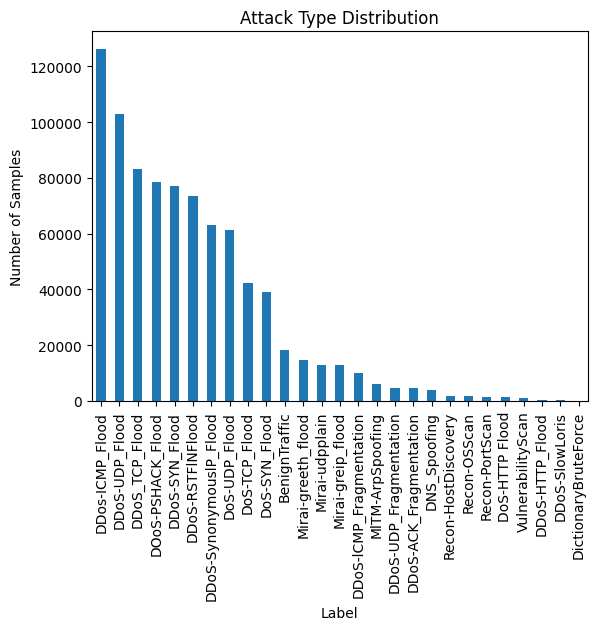

In [ ]:
#Maps numeric lables to attack type names
label_map = {
    1: 'Mirai-greeth_flood',
    4: 'DDoS-ACK_Fragmentation',
    5: 'DDoS-HTTP_Flood',
    6: 'DDos-ICMP_Flood',
    7: 'DDoS-lCMP_Fragmentation',
    8: 'DDoS-SYN_Flood',
    9: 'DDoS-RSTFlNFlood',
    10: 'DDoS_TCP_Flood',
    11: 'DDoS-SlowLoris',
    12: 'DDoS-SynonymouslP_Flood',
    13: 'DOoS-PSHACK_Flood',
    14: 'DDoS-UDP_Flood',
    15: 'DDoS-UDP_Fragmentation',
    16: 'DNS_Spoofing',
    18: 'Recon-OSScan',
    19: 'DoS-SYN_Flood',
    21: 'DoS-UDP_Flood',
    20: 'DoS-TCP_Flood',
    22: 'MlTM-ArpSpoofing',
    23: 'BenignTraffic',
    24: 'Mirai-udpplain',
    25: 'Mirai-greip_flood',
    26: 'Recon-HostDiscovery',
    27: 'VulnerabilityScan',
    29: 'Recon-PortScan',
    32: 'DoS-HTTP Flood',
    33: 'DictionaryBruteForce'
}

#Creates a new colums and replaces each number lable with attack type string
data['attack_name'] = data['label'].map(label_map)

#Counts how many samples belongs to each attack type
data['attack_name'].value_counts().plot(kind='bar')

plt.title('Attack Type Distribution')
plt.ylabel('Number of Samples')
plt.xlabel('Label')
plt.show()

#### Displays a flow duration boxplot that visualizes the distribution, spread, skewness, and precense of outliers in the feature, which helps understand the behavior of the network flow

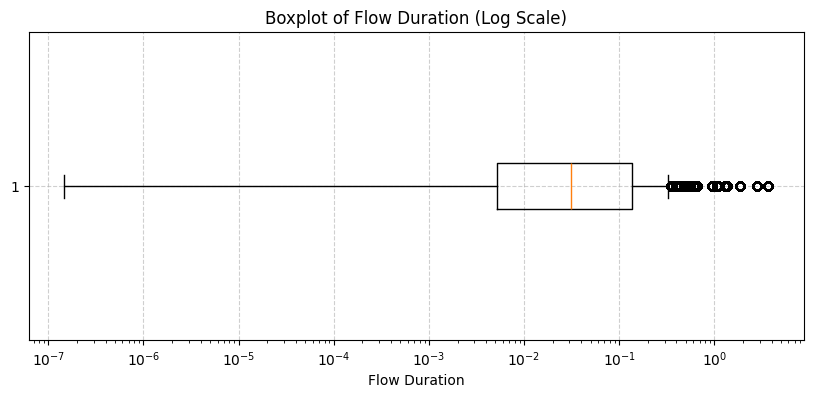

In [ ]:
col = 'flow_duration'
#Removes zero values because logarithmic scaling cannot handle zero values
non_zero = data[data[col] > 0][col]

plt.figure(figsize=(10, 4))
plt.boxplot(non_zero, vert=False)
plt.xscale('log')
plt.title('Boxplot of Flow Duration (Log Scale)')
plt.xlabel('Flow Duration')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Displays how frequently each network protocol appears in the dataset, helps understand the protocol destribution

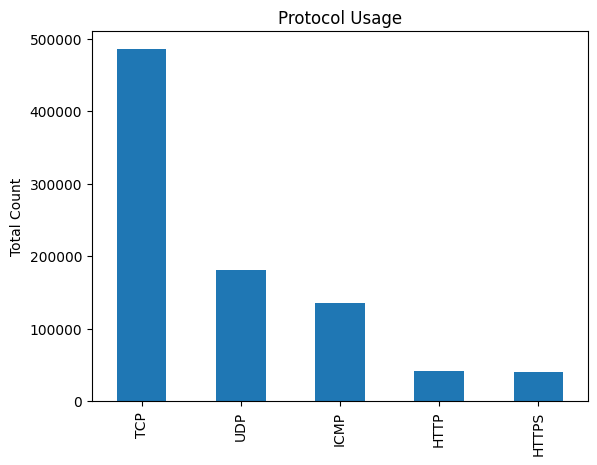

In [ ]:
protocols = ['TCP', 'UDP', 'ICMP', 'HTTP', 'HTTPS']
data[protocols].sum().plot(kind='bar')

plt.title('Protocol Usage')
plt.ylabel('Total Count')
plt.show()

#### Displays spearman correlations to capture monotonic relationships, helps with exploratory data analysis by visualizing the correlation with a heatmap

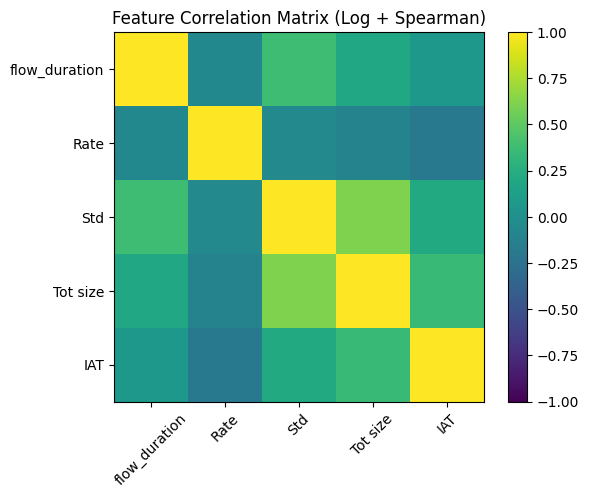

In [ ]:
selected = ['flow_duration', 'Rate', 'Std', 'Tot size', 'IAT']

#Ensures correlation is computer in meanningful values
filtered = data[selected].replace(0, np.nan).dropna()
#Applies logarithmic transformation to data
log_data = np.log1p(filtered.clip(lower=0))
#Calculates spearman correlation matrix on the transformed data
corr = log_data.corr(method='spearman')

plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(selected)), selected, rotation=45)
plt.yticks(range(len(selected)), selected)
plt.title('Feature Correlation Matrix (Log + Spearman)')
plt.show()

#### Displays the relation between two features, helps in identifying the patterns, trends, and anomalies

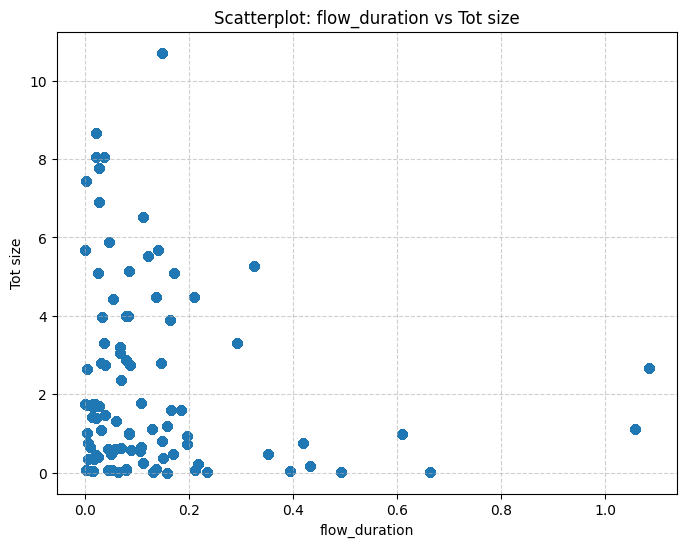

In [ ]:
x_feature = 'flow_duration'
y_feature = 'Tot size'

#Filters the dataset to only include positive x and y features
filtered_data = data[(data[x_feature] > 0) & (data[y_feature] > 0)]

plt.figure(figsize=(8,6))
plt.scatter(filtered_data[x_feature], filtered_data[y_feature], alpha=0.5)
plt.xlabel(x_feature)
plt.ylabel(y_feature)
plt.title(f'Scatterplot: {x_feature} vs {y_feature}')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Displays across multiple features at once, helps see how attacks cluster in feature space

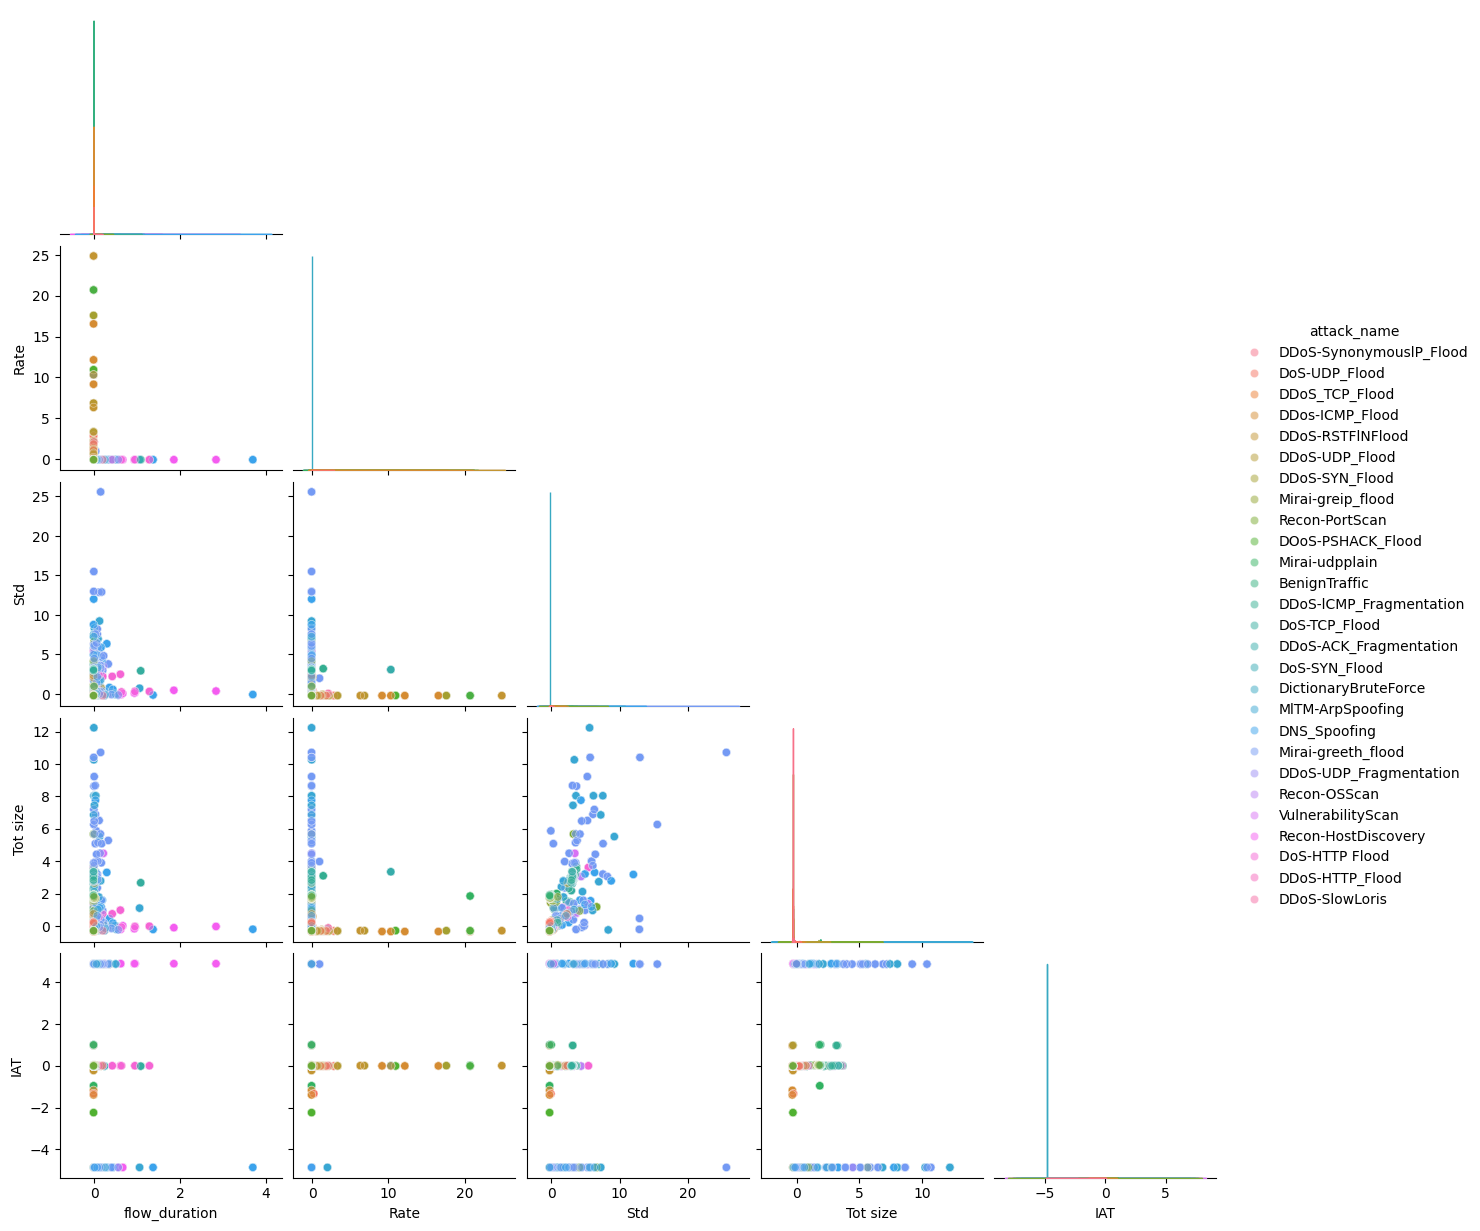

In [ ]:
selected_features = ['flow_duration', 'Rate', 'Std', 'Tot size', 'IAT']

#Takes a sample of the dataset since its too large
sample_data = data[selected_features + ['attack_name']].sample(5000, random_state=42)

sns.pairplot(sample_data, hue='attack_name', corner=True, plot_kws={'alpha':0.5})
plt.show()